In [173]:
import pandas as pd
import numpy as np
from utils import build_feature_matrix

### Feature Extraction & Outlier Analysis (3rd Iteration) ### 

In [187]:
# Read metadata and preprocess the image paths
metadata = pd.read_json("metadata.jsonl", lines=True)
metadata3 = pd.read_json("metadata3.jsonl", lines=True)
metadata3 = metadata3.drop(["id"],axis=1)
metadata3["is_outlier"] = False
metadata["image_path"] = metadata["image_path"].str.replace(
    "/content/drive/MyDrive/fruitveg_data/", "",
    regex=False
)
metadata = metadata[metadata["is_outlier"]==False] # Remove known outliers from first dataset
metadata3["image_path"] = metadata3["image_path"].str.replace(
    "/content/drive/MyDrive/fruitveg_data3/", "",
    regex=False
)
metadata3["image_path"] = metadata3["image_path"].str.replace(
    "images", "images3",
    regex=False)

In [3]:
# Build feature matrix
zip_path1 = "images.zip"
zip_path2 = "images2.zip"
zip_path3 = "images3.zip"
X1, paths1 = build_feature_matrix(zip_path1)
X2, paths2 = build_feature_matrix(zip_path2)
X3, paths3 = build_feature_matrix(zip_path3)
paths2 = np.char.replace(paths2, "images", "images2") # Adjust paths for second dataset
paths3 = np.char.replace(paths3, "images", "images3") # Adjust paths for third dataset

In [188]:
# Stack feature matrices
X = np.concatenate(([X1, X2, X3]), axis=0)
paths = np.concatenate(([paths1, paths2, paths3]), axis=0)

In [189]:
# Create DataFrame with features and paths
n_samples, n_features = X.shape
feature_cols = [f"f{i}" for i in range(n_features)]
df_feats = pd.DataFrame(X, columns=feature_cols)
df_feats["path"] = paths

In [190]:
# Merge features with metadata
df = df_feats.merge(pd.concat([metadata, metadata3]), left_on="path", right_on="image_path", how="inner")

In [191]:
feature_cols = [c for c in df.columns if c.startswith("f")]

# Group by class and z-score *within each class*
def zscore_group(g):
    return (g - g.mean()) / g.std()

df_z = df.groupby("class")[feature_cols].transform(zscore_group)


In [192]:
df["outlier_score"] = df_z.abs().mean(axis=1)
threshold = 2
df["is_outlier"] = df["outlier_score"] > threshold

In [193]:
df.groupby("class")["is_outlier"].sum()

class
apple       8
banana      1
cucumber    2
orange      8
tomato      1
Name: is_outlier, dtype: int64

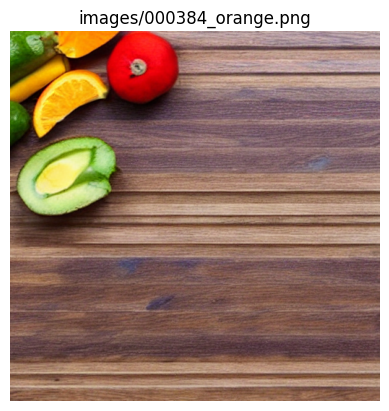

In [218]:
import zipfile
from PIL import Image
import matplotlib.pyplot as plt

zip_path = "images.zip"
img_name = df[df["is_outlier"]==True].reset_index().loc[2,"image_path"]

with zipfile.ZipFile(zip_path, 'r') as z:
    with z.open(img_name) as f:
        img = Image.open(f).convert("RGB")

plt.imshow(img)
plt.axis("off")
plt.title(img_name)
plt.show()


### This time wont exclude outliers. The dataset is ready after 3rd iteration.

In [ ]:
# Update the metadata with outlier information including second dataset's metadata
metadata_final = pd.concat([metadata, metadata3]).merge(
    df[["image_path", "is_outlier"]],
    on="image_path",
    how="inner"
)
def is_outlier(row):
    if row["is_outlier_x"] or row["is_outlier_y"]:
        return True 
    return False
metadata_final["is_outlier"] = metadata_final.apply(is_outlier, axis=1)
metadata_final = metadata_final.drop(["is_outlier_x", "is_outlier_y"], axis=1)
metadata_final.to_json("metadata.jsonl", orient="records", lines=True)